In [1]:
import pandas as pd
from CCA_utils import *

## Baseline Model Panel

In [2]:
study_sovereigns = [
    'Saudi Arabia', 'Abu Dhabi', 'Dubai', 'Qatar', 'Colombia',
    'Mexico', 'Brazil', 'Egypt', 'Malaysia','Indonesia', 'Philippines', 'Turkey', 'Chile', 'China',
    'South Africa', 'South Korea', 'Thailand']

cca_panel_df = pd.read_csv('../data/processed/CCA/cca_newfx_rates.csv')
cca_panel_df['date'] = pd.to_datetime(cca_panel_df['date'])
cca_panel_df = cca_panel_df[cca_panel_df['country'].isin(study_sovereigns)].copy()
cca_panel_df.drop(columns=['cds_spread_1Y'], inplace=True)
cca_panel_df.rename(columns={'cds_spread_5Y': 'cds_spread'}, inplace=True)


T=1.0
vol_window = 12
freq = 'ME'

cca_panel_df['domestic_rate_in_units'] = cca_panel_df['domestic_rate_in_units']/100
cca_panel_df['risk_free_rate'] = cca_panel_df['risk_free_rate']/100
cca_panel_df['monetary_base_mn_localcurr'] = cca_panel_df['monetary_base_mn_localcurr'] / 1000
cca_panel_df['domestic_debt_bn_localcurr'] = cca_panel_df['domestic_debt_bn_localcurr']
cca_panel_df['external_debt_mn_usd'] = cca_panel_df['external_debt_mn_usd']/1000

## Model 1: Specific data

In [3]:

#Join oil prices and oil futures
oil_prices = pd.read_csv('../data/processed/Oil/oil_prices_datastream.csv')
oil_prices['date'] = pd.to_datetime(oil_prices['date'])
oil_futures = pd.read_csv('../data/processed/Oil/oil_futures.csv')
oil_futures['date'] = pd.to_datetime(oil_futures['date'])

cca_panel_df = cca_panel_df.merge(oil_prices[['date','Brent']], on='date', how='left')
cca_panel_df = cca_panel_df.merge(oil_futures[['date','Brent_12m']],on='date',how='left')

oil_prod = pd.read_csv('../data/processed/Oil/crude_oil_production.csv')
oil_prod = oil_prod.rename(columns={oil_prod.columns[0]: 'country'})
oil_prod = oil_prod.melt(id_vars='country', var_name='year', value_name='oil_production_Mt_yr')
oil_prod['year'] = oil_prod['year'].astype(int)

# UAE for Abu Dhabi and Dubai
uae = oil_prod[oil_prod['country'] == 'United Arab Emirates'].copy()
for name in ['Abu Dhabi', 'Dubai']:
    rows = uae.copy()
    rows['country'] = name
    oil_prod = pd.concat([oil_prod, rows], ignore_index=True)

cca_panel_df['year'] = cca_panel_df['date'].dt.year
cca_panel_df = cca_panel_df.merge(oil_prod[['year', 'country', 'oil_production_Mt_yr']], 
                                   on=['country', 'year'], how='left')
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].fillna(0)
cca_panel_df['oil_production_Mt_yr'] = cca_panel_df['oil_production_Mt_yr'].astype(int)

cca_panel_df.set_index(['date','country'], inplace=True)
cca_panel_df = (
    cca_panel_df
    .groupby('country')
    .resample('ME', level='date')
    .last()
)
cca_panel_df.reset_index(inplace=True)
cca_panel_df

C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_40004\217007680.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil_prices['date'] = pd.to_datetime(oil_prices['date'])
C:\Users\JuanFranciscoPerez\AppData\Local\Temp\ipykernel_40004\217007680.py:5: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  oil_futures['date'] = pd.to_datetime(oil_futures['date'])


,country,date,Unnamed: 0,year,quarter,month,week,cds_spread,msci_index,monetary_base_mn_localcurr,domestic_debt_bn_localcurr,external_debt_mn_usd,domestic_rate_in_units,risk_free_rate,fx_rate,Brent,Brent_12m,oil_production_Mt_yr
0,Abu Dhabi,2014-01-31,13780,2014,1.0,1.0,5.0,56.32999,804.960,288.310000,210.154,22.889480,0.01,0.0010,3.672960,107.13,101.63,170
1,Abu Dhabi,2014-02-28,13784,2014,1.0,2.0,9.0,54.78999,867.273,287.846000,210.154,22.889480,0.01,0.0012,3.672960,109.10,104.26,170
2,Abu Dhabi,2014-03-31,13788,2014,1.0,3.0,13.0,53.81999,895.321,297.840000,210.154,22.889480,0.01,0.0013,3.672960,107.74,103.54,170
3,Abu Dhabi,2014-04-30,13792,2014,2.0,4.0,17.0,51.34000,1030.704,293.257000,210.154,22.889480,0.01,0.0011,3.673095,109.43,103.96,170
4,Abu Dhabi,2014-05-31,13797,2014,2.0,5.0,22.0,44.79999,1043.794,296.941000,210.154,22.889480,0.01,0.0010,3.672960,109.56,103.89,170
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,Turkey,2024-08-31,13184,2024,3.0,8.0,35.0,265.75000,613.356,6157.194895,10716.668,157.127935,0.50,0.0438,34.071550,78.89,73.76,6
2240,Turkey,2024-09-30,13188,2024,3.0,9.0,39.0,267.87010,631.258,6175.969703,10716.668,157.127935,0.50,0.0390,34.129693,71.66,70.55,6
2241,Turkey,2024-10-31,13192,2024,4.0,10.0,43.0,271.25000,550.218,6099.357409,10716.668,157.127935,0.50,0.0429,34.246575,75.88,73.37,6
2242,Turkey,2024-11-30,13197,2024,4.0,11.0,48.0,251.12000,610.455,6067.888530,10716.668,157.127935,0.50,0.0430,34.722222,73.20,69.95,6


In [8]:
results = pd.DataFrame()
eta = 0.5

for country, group in cca_panel_df.groupby('country'):

    df = group.copy().sort_values('date').reset_index(drop=True)
        
    # --- Unit conversions ---
    r_d = df['domestic_rate_in_units']
    r_f = df['risk_free_rate']
    M_bn = df['monetary_base_mn_localcurr']
    dom_D_bn = df['domestic_debt_bn_localcurr']
    ext_D_bn = df['external_debt_mn_usd']
    fx_rate = df['fx_rate']


    # --- LCL$ ---
    df['LCL_usd'] = [
        compute_lcl_usd(m, bd, fx, rd, rf, T)
        for m, bd, fx, rd, rf in zip(
            M_bn, dom_D_bn, fx_rate, r_d, r_f
        )
    ]

        # --- Barrier ---
    df['B_f'] = [
            compute_barrier_kvm(debt, rf, T)
            for debt, rf in zip(
                df['external_debt_mn_usd'], r_f
            )
        ]

    df['futures_term'] = (df['Brent_12m']/df['Brent']) ** eta
    df['LCL_aug'] = df['LCL_usd'] * df['futures_term']


    ann_factor = np.sqrt(52) if freq == 'W' else np.sqrt(12)
    log_ret = np.log(df['LCL_aug'] / df['LCL_aug'].shift(1))
    
    df['sigma_lcl'] = log_ret.rolling(window=vol_window).std() * ann_factor

    # --- Solve CCA with augmented LCL ---
    out = {k: [] for k in ['implied_V', 'implied_sigma_V', 'cca_converged',
                            'distance_to_distress', 'default_prob',
                            'model_spread_bps', 'put_value', 'risky_debt',
                            'leverage']}

    for i, row in df.iterrows():
        cca = solve_CCA(row['LCL_aug'], row['sigma_lcl'], row['B_f'],
                        r_f.iloc[i], T)
        risk = compute_risk(cca['V'], cca['sigma_V'], row['B_f'],
                           r_f.iloc[i], T)

        out['implied_V'].append(cca['V'])
        out['implied_sigma_V'].append(cca['sigma_V'])
        out['cca_converged'].append(cca['converged'])
        out['distance_to_distress'].append(risk['d2'])
        out['default_prob'].append(risk['default_prob'])
        out['model_spread_bps'].append(risk['credit_spread_bps'])
        out['put_value'].append(risk['put_value'])
        out['risky_debt'].append(risk['risky_debt'])
        out['leverage'].append(risk['leverage'])

    for col, vals in out.items():
        df[col] = vals

    results = pd.concat([results, df])


START_DATE = '2015-01-01'
END_DATE = '2024-12-31'

results = results[
    (results['date'] >= START_DATE) & (results['date'] <= END_DATE)
].copy()


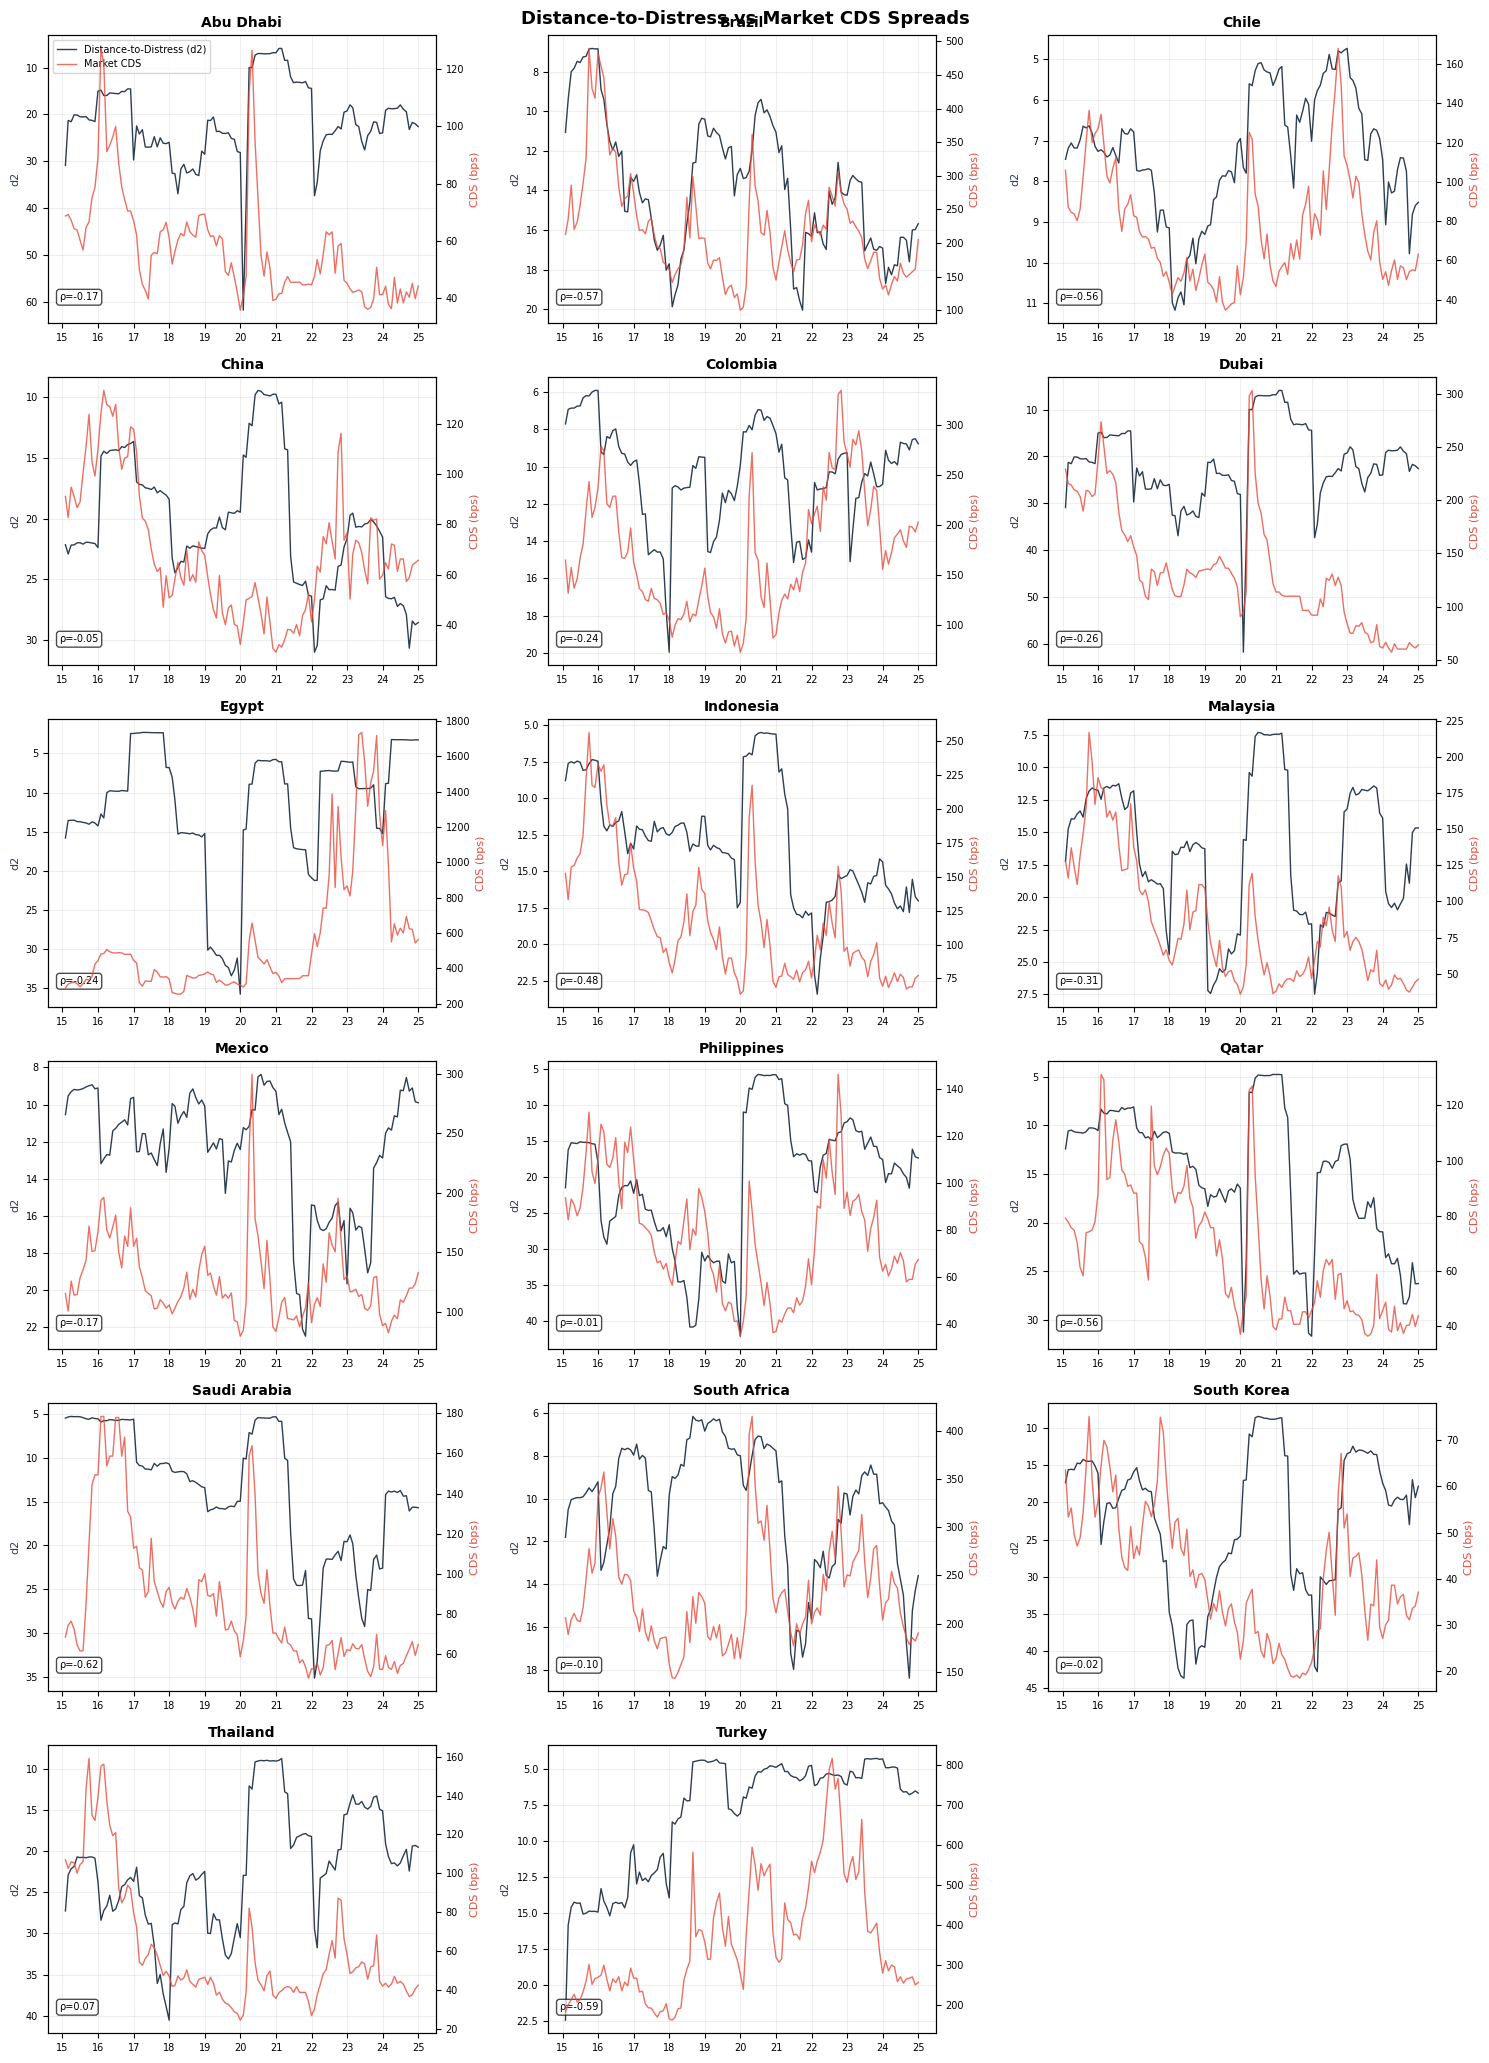

In [9]:
d2_vs_cds = plot_d2_vs_cds(results)

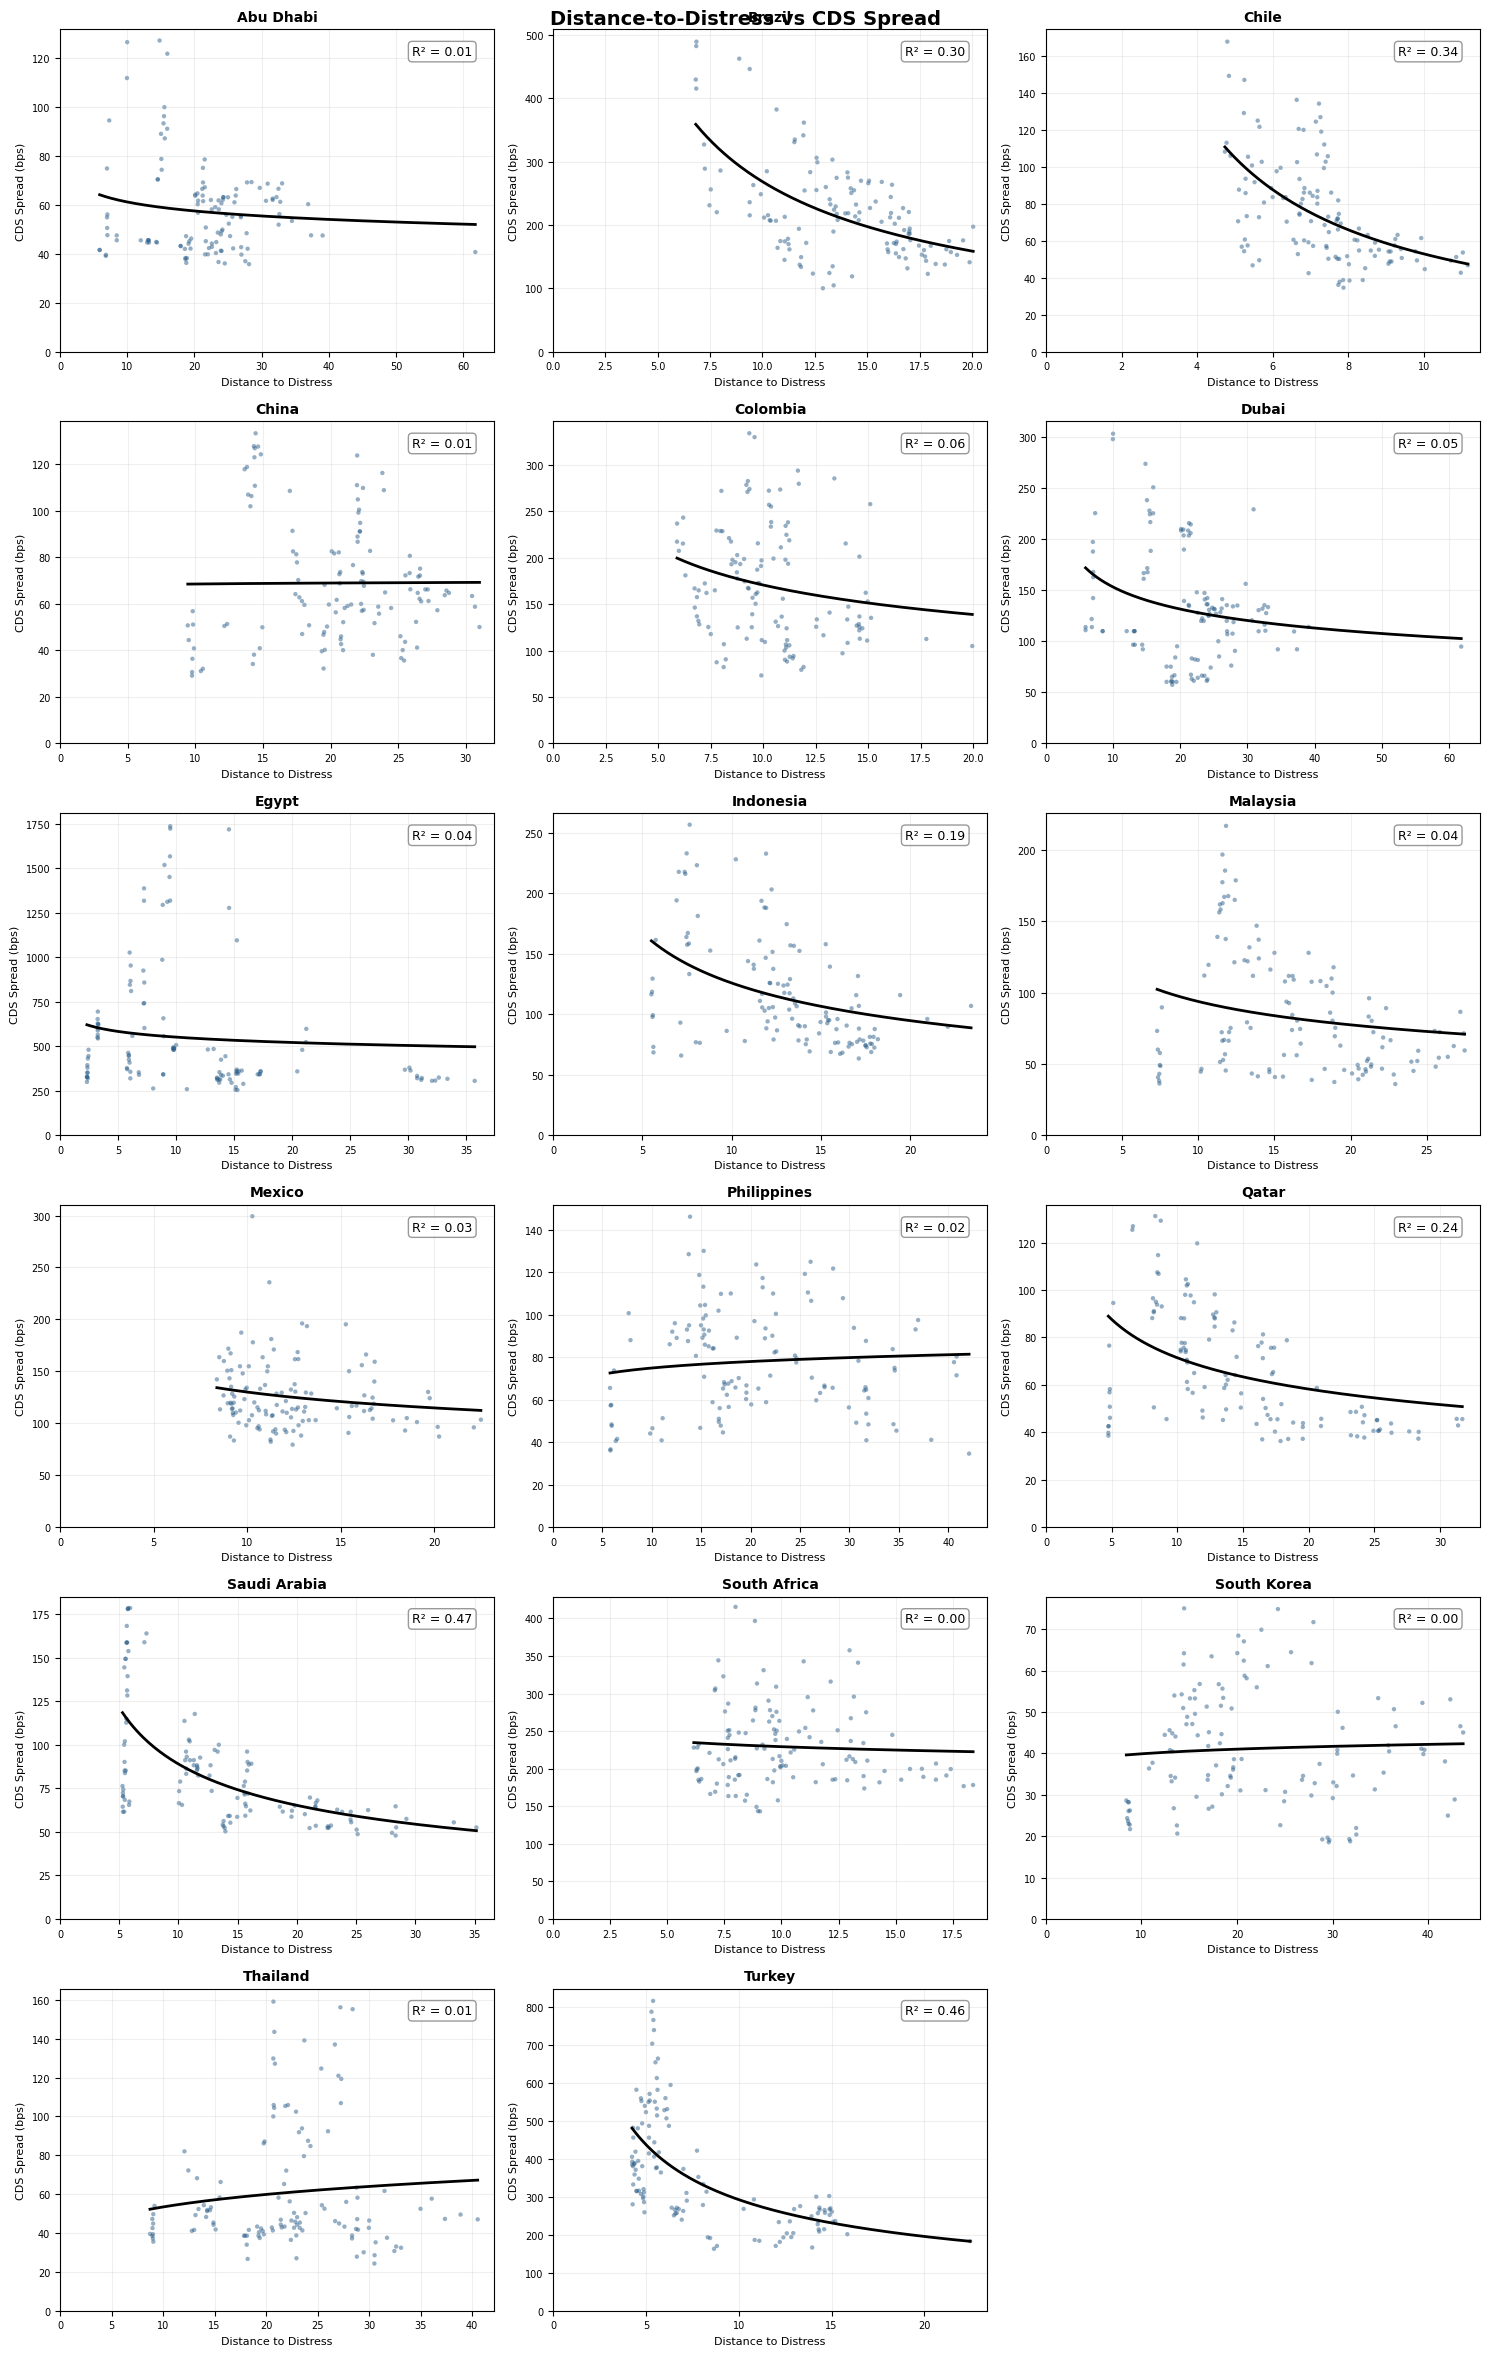

In [10]:
d2_scatter = plot_d2_scatter(results)

In [12]:
display, raw = correlation_table(
    results,
    dd_col='distance_to_distress',
    horizons=[1, 3, 6],
    horizon_labels=['1m', '3m', '6m'],
)
display

,Country,N,ρ (1m),ρ_S (1m),Dir (1m),ρ (3m),ρ_S (3m),Dir (3m),ρ (6m),ρ_S (6m),Dir (6m)
0,Abu Dhabi,120,-0.28***,-0.08,55%,-0.44***,-0.13,53%,-0.27***,-0.21,54%
1,Brazil,120,-0.30***,-0.32,64%,-0.37***,-0.43,69%,-0.46***,-0.52,81%
2,Chile,120,-0.27***,-0.21,54%,-0.33***,-0.37,68%,-0.41***,-0.43,72%
3,China,120,-0.08,-0.17,55%,-0.11,-0.15,55%,-0.10,-0.11,56%
4,Colombia,120,-0.03,-0.09,56%,-0.08,-0.06,54%,-0.20**,-0.23,61%
5,Dubai,120,-0.41***,-0.08,55%,-0.53***,-0.14,56%,-0.43***,-0.34,61%
6,Egypt,120,0.03,0.02,52%,0.05,0.09,44%,-0.06,-0.09,49%
7,Indonesia,120,0.04,0.12,51%,-0.16*,-0.04,50%,-0.27***,-0.15,58%
8,Malaysia,120,-0.14,-0.13,51%,-0.31***,-0.26,51%,-0.30***,-0.26,52%
9,Mexico,120,-0.01,-0.03,51%,-0.04,-0.01,50%,-0.09,-0.16,61%


In [ ]:
results.to_csv("../output/results/M1_results.csv")